<a href="https://colab.research.google.com/github/Maryam-Yaqoob/ANN-LAB/blob/main/FA23_BAI_025___Assignment_1___Maryam_Yaqoob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMSATS University Islamabad
## Department of Computer Science
### Lab Assignment 1 — ANN & DL  [Marks 10]

| | |
|---|---|
| **Name** | Maryam Yaqoob |
| **Registration No.** | FA23-BAI-025 |
| **Class** | BSAI-7 |
| **Subject** | Artificial Neural Networks & Deep Learning |

**Assumptions (flagged up-front):**
1. Class is written as BSAI-7 (the sheet lists BSAI-6 & 7 / BDS-7) — edit if needed.
2. M-P neuron fires when `weighted_sum >= threshold`.
3. "Converged" in Tasks 3 and 4 means **MSE < 0.01** (which on XOR also means all 4 outputs are classified correctly at a 0.5 cut-off).
4. In the Task 3 experiment, each (hidden, lr) setting is run with **5 random seeds**; the table reports the median epochs among converged runs and how many of the 5 converged, with a cap of 50,000 epochs.
5. Task 4 definitions: `zero` = all weights/biases 0; `random` = N(0, 1); `xavier` = Glorot uniform, limit = sqrt(6/(fan_in+fan_out)); `he` = N(0, 2/fan_in). Biases start at 0 for every scheme.

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)

# Common XOR / AND / OR data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

---
# Task 1 — McCulloch-Pitts (M-P) Neuron

The M-P neuron computes a weighted sum of binary inputs and fires (outputs 1) if the sum reaches a threshold θ:

$$ y = \begin{cases} 1 & \text{if } \sum_i w_i x_i \ge \theta \\ 0 & \text{otherwise} \end{cases} $$

In [ ]:
def mp_neuron(inputs, weights, threshold):
    """McCulloch-Pitts neuron.
    inputs, weights : array-likes of equal length
    threshold       : firing threshold (neuron fires if sum >= threshold)
    returns         : 0 or 1
    """
    weighted_sum = np.dot(inputs, weights)
    return int(weighted_sum >= threshold)


def truth_table(name, n_inputs, weights, threshold, expected_fn):
    """Print inputs, weighted sum, output (and expected output) for every input combo."""
    rows = []
    for x in itertools.product([0, 1], repeat=n_inputs):
        s = np.dot(x, weights)
        out = mp_neuron(x, weights, threshold)
        row = {f"x{i+1}": v for i, v in enumerate(x)}
        row.update({"weighted_sum": s, "output": out, "expected": int(expected_fn(*x))})
        rows.append(row)
    df = pd.DataFrame(rows)
    df["match"] = df["output"] == df["expected"]
    print(f"{name}   weights = {list(weights)}, threshold = {threshold}")
    print(df.to_string(index=False))
    print("All rows correct:", bool(df["match"].all()), "\n")
    return df

## 1(a) AND gate (2-input) — derivation
We need output 1 **only** for (1,1). Try w₁ = w₂ = 1:
- sums are 0, 1, 1, 2 for (0,0), (0,1), (1,0), (1,1)
- only the last must fire ⇒ choose **θ = 2** (since 1 < 2 ≤ 2).

**Weights = [1, 1], θ = 2.**

In [ ]:
df_and = truth_table('AND', 2, [1, 1], 2, lambda a, b: a and b)

AND   weights = [1, 1], threshold = 2
 x1  x2  weighted_sum  output  expected  match
  0   0             0       0         0   True
  0   1             1       0         0   True
  1   0             1       0         0   True
  1   1             2       1         1   True
All rows correct: True 



## 1(b) OR gate (2-input) — derivation
Output 1 for every input except (0,0). With w₁ = w₂ = 1 the sums are 0, 1, 1, 2.
(0,0) must not fire (0 < θ) while all others must (1 ≥ θ) ⇒ **θ = 1**.

**Weights = [1, 1], θ = 1.**

In [ ]:
df_or = truth_table('OR', 2, [1, 1], 1, lambda a, b: a or b)

OR   weights = [1, 1], threshold = 1
 x1  x2  weighted_sum  output  expected  match
  0   0             0       0         0   True
  0   1             1       1         1   True
  1   0             1       1         1   True
  1   1             2       1         1   True
All rows correct: True 



## 1(c) NOT gate (1-input, negative weight) — derivation
Need: x = 0 → 1 and x = 1 → 0. Use w = −1: sums are 0 (x=0) and −1 (x=1).
x = 0 must fire: 0 ≥ θ; x = 1 must not: −1 < θ ⇒ choose **θ = 0** (any −1 < θ ≤ 0 works).

**Weights = [−1], θ = 0.**

In [ ]:
df_not = truth_table('NOT', 1, [-1], 0, lambda a: not a)

NOT   weights = [-1], threshold = 0
 x1  weighted_sum  output  expected  match
  0             0       1         1   True
  1            -1       0         0   True
All rows correct: True 



## 1(d) AND gate for 3 inputs — derivation
Output 1 only for (1,1,1). With all weights = 1 the sum equals the number of 1s (0..3).
Only the sum 3 must fire ⇒ **θ = 3**.

**Weights = [1, 1, 1], θ = 3.**

In [ ]:
df_and3 = truth_table('AND-3', 3, [1, 1, 1], 3, lambda a, b, c: a and b and c)

AND-3   weights = [1, 1, 1], threshold = 3
 x1  x2  x3  weighted_sum  output  expected  match
  0   0   0             0       0         0   True
  0   0   1             1       0         0   True
  0   1   0             1       0         0   True
  0   1   1             2       0         0   True
  1   0   0             1       0         0   True
  1   0   1             2       0         0   True
  1   1   0             2       0         0   True
  1   1   1             3       1         1   True
All rows correct: True 



## 1(e) Attempt XOR with a single M-P neuron
XOR requires, for weights w₁, w₂ and threshold θ:

| input | requirement |
|---|---|
| (0,0) → 0 | 0 < θ |
| (0,1) → 1 | w₂ ≥ θ |
| (1,0) → 1 | w₁ ≥ θ |
| (1,1) → 0 | w₁ + w₂ < θ |

From the middle two: w₁ + w₂ ≥ 2θ. Since θ > 0 we get 2θ > θ, so w₁ + w₂ > θ — which **contradicts** the last row (w₁ + w₂ < θ). So no choice of (w₁, w₂, θ) can work. We also confirm this by brute-force search below.

In [ ]:
grid = np.arange(-3, 3.01, 0.5)
solutions = []
for w1, w2, th in itertools.product(grid, grid, grid):
    if all(mp_neuron(x, [w1, w2], th) == t for x, t in zip(X, y_xor)):
        solutions.append((w1, w2, th))

print(f"Searched {len(grid)**3} (w1, w2, theta) combinations on a grid in [-3, 3].")
print("Combinations that realise XOR:", len(solutions))

# Show the best a single M-P neuron can do (max number of correct rows)
best, best_params = -1, None
for w1, w2, th in itertools.product(grid, grid, grid):
    correct = sum(mp_neuron(x, [w1, w2], th) == t for x, t in zip(X, y_xor))
    if correct > best:
        best, best_params = correct, (w1, w2, th)
print(f"Best possible: {best}/4 rows correct, e.g. (w1, w2, theta) = {tuple(float(v) for v in best_params)}")

Searched 2197 (w1, w2, theta) combinations on a grid in [-3, 3].
Combinations that realise XOR: 0
Best possible: 3/4 rows correct, e.g. (w1, w2, theta) = (-3.0, -3.0, -3.0)


**Conclusion:** XOR is *not* realisable with a single M-P neuron because XOR is not linearly separable (explained further in Task 2).

---
# Task 2 — Perceptron

Perceptron learning rule (step activation, output ∈ {0, 1}):

$$ \hat y = \text{step}(\mathbf w \cdot \mathbf x + b), \qquad \mathbf w \leftarrow \mathbf w + \eta (y-\hat y)\mathbf x, \quad b \leftarrow b + \eta (y - \hat y) $$

In [ ]:
class Perceptron:
    """Single perceptron with step activation."""

    def __init__(self, n_features=2):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.errors_ = []          # misclassifications per epoch

    @staticmethod
    def _step(z):
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        X = np.atleast_2d(X)
        return self._step(X @ self.w + self.b)

    def fit(self, X, y, epochs=50, lr=0.1, stop_when_converged=True):
        self.errors_ = []
        for _ in range(epochs):
            errors = 0
            for xi, target in zip(X, y):
                pred = self.predict(xi)[0]
                update = lr * (target - pred)
                self.w = self.w + update * xi
                self.b = self.b + update
                errors += int(update != 0.0)
            self.errors_.append(errors)
            if stop_when_converged and errors == 0:
                break
        return self


def plot_boundary(ax, model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["#f4b6b6", "#b6d4f4"], alpha=0.6)
    ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="red", s=120, edgecolors="k", label="class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", s=120, edgecolors="k", label="class 1")
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_title(title); ax.legend(loc="upper right")

## 2(a) Train on AND and OR — decision boundary and misclassifications per epoch

AND: converged in 4 epochs, w = [0.2 0.1], b = -0.20, predictions = [0 0 0 1]
OR: converged in 4 epochs, w = [0.1 0.1], b = -0.10, predictions = [0 1 1 1]


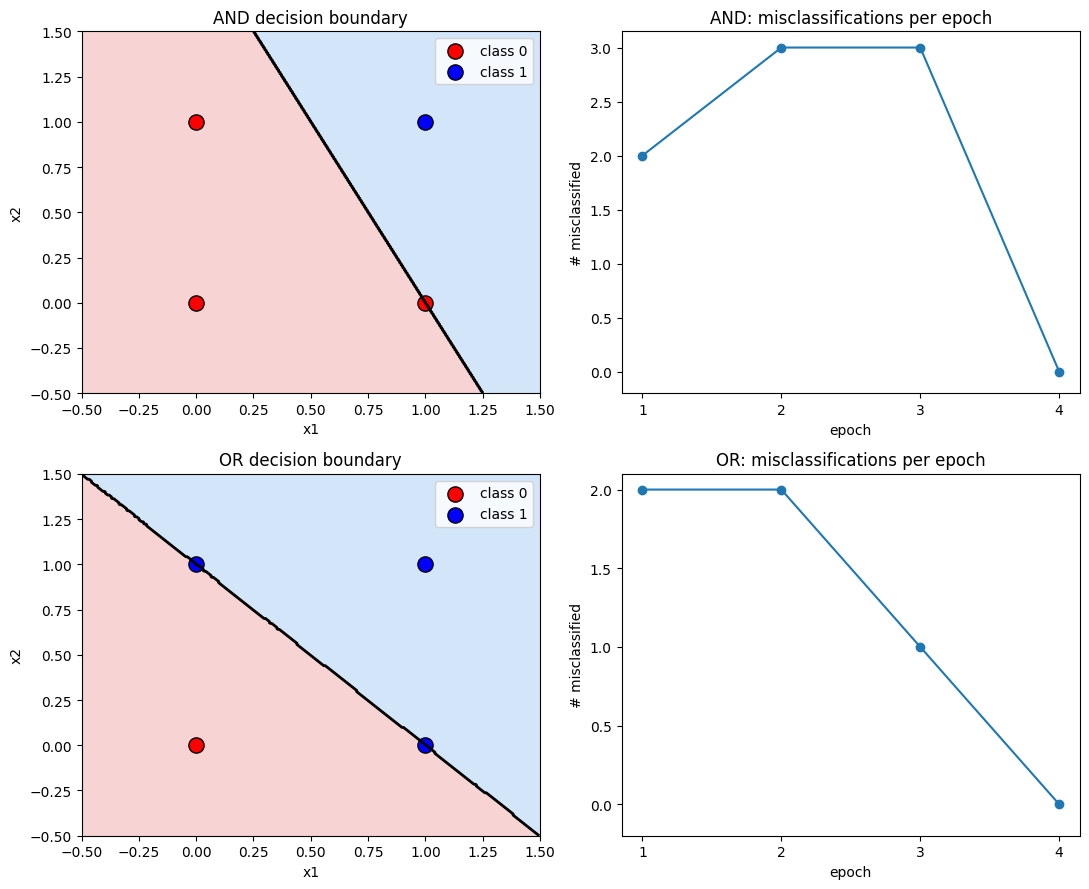

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
models = {}
for row, (name, yt) in enumerate([("AND", y_and), ("OR", y_or)]):
    p = Perceptron(2).fit(X, yt, epochs=50, lr=0.1)
    models[name] = p
    print(f"{name}: converged in {len(p.errors_)} epochs, w = {p.w}, b = {p.b:.2f}, "
          f"predictions = {p.predict(X)}")
    plot_boundary(axes[row, 0], p, X, yt, f"{name} decision boundary")
    axes[row, 1].plot(range(1, len(p.errors_) + 1), p.errors_, marker="o")
    axes[row, 1].set_title(f"{name}: misclassifications per epoch")
    axes[row, 1].set_xlabel("epoch"); axes[row, 1].set_ylabel("# misclassified")
    axes[row, 1].set_ylim(bottom=-0.2)
    axes[row, 1].xaxis.get_major_locator().set_params(integer=True)
plt.tight_layout(); plt.show()

## 2(b) Attempt XOR with the same perceptron — it never converges

Misclassifications in the last 10 epochs: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Minimum errors in any epoch: 3


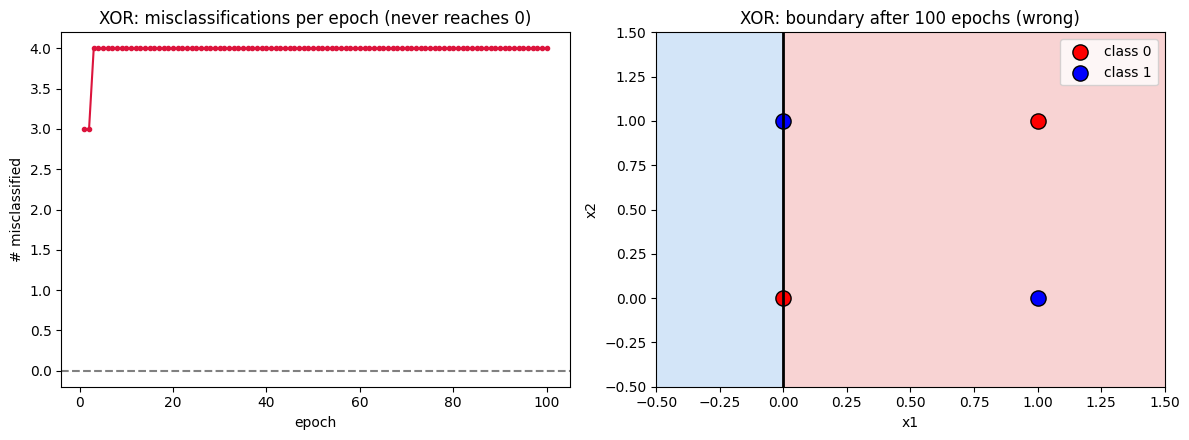

In [ ]:
p_xor = Perceptron(2).fit(X, y_xor, epochs=100, lr=0.1, stop_when_converged=False)
print("Misclassifications in the last 10 epochs:", p_xor.errors_[-10:])
print("Minimum errors in any epoch:", min(p_xor.errors_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(range(1, 101), p_xor.errors_, marker=".", color="crimson")
axes[0].axhline(0, color="gray", ls="--")
axes[0].set_title("XOR: misclassifications per epoch (never reaches 0)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("# misclassified")
plot_boundary(axes[1], p_xor, X, y_xor, "XOR: boundary after 100 epochs (wrong)")
plt.tight_layout(); plt.show()

## 2(c) Why it fails — linear separability

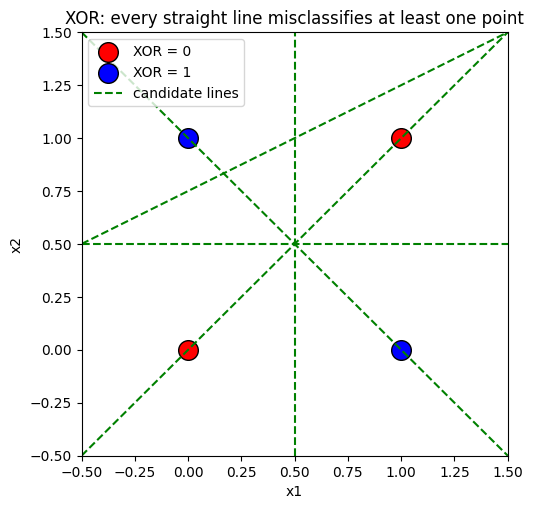

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(X[y_xor == 0, 0], X[y_xor == 0, 1], c="red", s=200, edgecolors="k", label="XOR = 0")
ax.scatter(X[y_xor == 1, 0], X[y_xor == 1, 1], c="blue", s=200, edgecolors="k", label="XOR = 1")
xs = np.linspace(-0.5, 1.5, 50)
ax.plot(xs, 0.5 + 0 * xs, "g--", label="candidate lines")
ax.plot(0.5 + 0 * xs, xs, "g--")
ax.plot(xs, xs, "g--")
ax.plot(xs, 1 - xs, "g--")
ax.plot(xs, 0.5 * xs + 0.75, "g--")
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("XOR: every straight line misclassifies at least one point")
ax.legend(); plt.show()

**Explanation.** A perceptron outputs 1 when **w·x + b ≥ 0**, i.e. it splits the plane with a *single straight line*. A problem is solvable only if the two classes are **linearly separable**.

For XOR the class-1 points are (0,1) and (1,0), and the class-0 points are (0,0) and (1,1). The two class-1 points lie on one diagonal and the class-0 points on the other, so the segments joining each pair cross at (0.5, 0.5). Any half-plane that contains both blue points contains their midpoint (0.5, 0.5) (half-planes are convex), but that same midpoint is also the midpoint of the two red points, so the half-plane would contain a red point too. Hence **no straight line can separate XOR**, and the perceptron learning rule keeps flipping its weights forever (the error never reaches 0). The perceptron convergence theorem only guarantees convergence for linearly separable data.

Fix: add a **hidden layer** (Task 3), which lets the network build a non-linear decision boundary.

---
# Task 3 — 2-layer MLP from scratch (NumPy)

**Architecture:** input (2) → hidden (sigmoid) → output (1, sigmoid). **Loss:** MSE.

### Forward pass
$$ z_1 = XW_1 + b_1,\quad a_1 = \sigma(z_1),\quad z_2 = a_1W_2 + b_2,\quad \hat y = a_2 = \sigma(z_2) $$
$$ L = \frac{1}{N}\sum (\hat y - y)^2 $$

### Backpropagation (derivation)
Using σ'(z) = σ(z)(1 − σ(z)):

- Output layer: $\dfrac{\partial L}{\partial a_2} = \dfrac{2}{N}(a_2 - y)$, so  
  $\delta_2 = \dfrac{\partial L}{\partial z_2} = \dfrac{2}{N}(a_2 - y)\,a_2(1-a_2)$
- $\dfrac{\partial L}{\partial W_2} = a_1^{T}\delta_2,\qquad \dfrac{\partial L}{\partial b_2} = \sum \delta_2$
- Hidden layer: $\delta_1 = (\delta_2 W_2^{T}) \odot a_1(1-a_1)$
- $\dfrac{\partial L}{\partial W_1} = X^{T}\delta_1,\qquad \dfrac{\partial L}{\partial b_1} = \sum \delta_1$

Update (full-batch gradient descent): $\theta \leftarrow \theta - \eta\,\partial L/\partial\theta$.

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


class MLP:
    """2-layer MLP (input -> sigmoid hidden -> sigmoid output), MSE loss, full-batch GD."""

    def __init__(self, n_in=2, n_hidden=2, n_out=1, lr=0.5, seed=0, conv_tol=0.01):
        self.n_in, self.n_hidden, self.n_out = n_in, n_hidden, n_out
        self.lr, self.conv_tol = lr, conv_tol
        self.rng = np.random.default_rng(seed)
        self._init_params()

    def _init_params(self):
        # Task 3 default: random N(0, 1) weights, zero biases
        self.W1 = self.rng.standard_normal((self.n_in, self.n_hidden))
        self.b1 = np.zeros((1, self.n_hidden))
        self.W2 = self.rng.standard_normal((self.n_hidden, self.n_out))
        self.b2 = np.zeros((1, self.n_out))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        N = X.shape[0]
        d2 = (2.0 / N) * (self.a2 - y) * self.a2 * (1 - self.a2)   # dL/dz2
        dW2 = self.a1.T @ d2
        db2 = d2.sum(axis=0, keepdims=True)
        d1 = (d2 @ self.W2.T) * self.a1 * (1 - self.a1)            # dL/dz1
        dW1 = X.T @ d1
        db1 = d1.sum(axis=0, keepdims=True)
        return dW1, db1, dW2, db2

    def fit(self, X, y, epochs=10000, stop_on_converge=False):
        y = y.reshape(-1, 1)
        self.losses_ = []
        self.converged_epoch_ = None
        for ep in range(1, epochs + 1):
            out = self.forward(X)
            loss = np.mean((out - y) ** 2)
            self.losses_.append(loss)
            if self.converged_epoch_ is None and loss < self.conv_tol:
                self.converged_epoch_ = ep
                if stop_on_converge:
                    break
            dW1, db1, dW2, db2 = self.backward(X, y)
            self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        return self

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int).ravel()

## 3(a) Train on XOR, plot loss and learned decision boundary (4 hidden neurons, lr = 1.0)

Final MSE: 0.00034014641189203295
Epochs to reach MSE < 0.01: 1258
Predicted probabilities: [0.007 0.981 0.981 0.024]
Predicted classes      : [0 1 1 0]  target: [0 1 1 0]


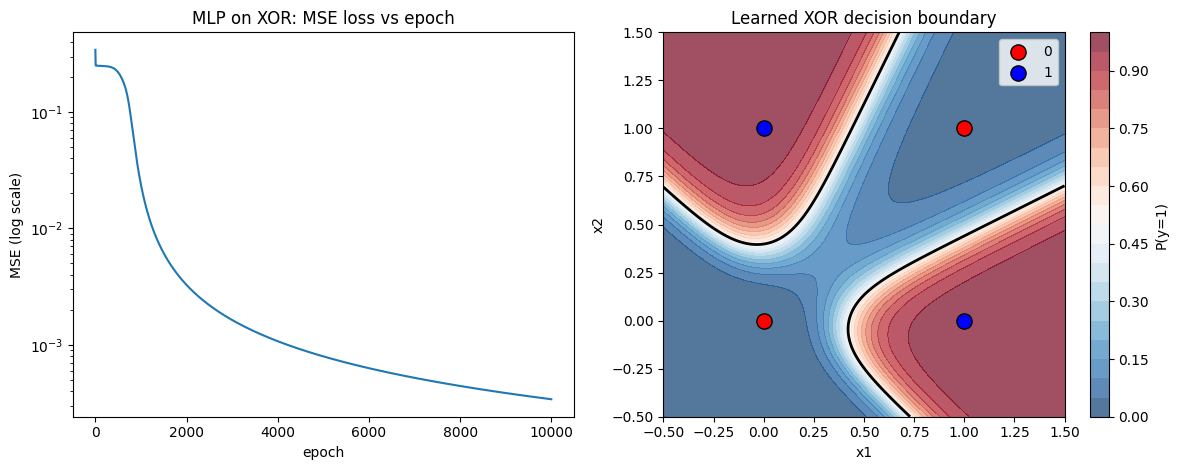

In [ ]:
mlp = MLP(n_hidden=4, lr=1.0, seed=0).fit(X, y_xor, epochs=10000)
print("Final MSE:", mlp.losses_[-1])
print("Epochs to reach MSE < 0.01:", mlp.converged_epoch_)
print("Predicted probabilities:", mlp.predict_proba(X).ravel().round(3))
print("Predicted classes      :", mlp.predict(X), " target:", y_xor)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(mlp.losses_)
axes[0].set_yscale("log")
axes[0].set_title("MLP on XOR: MSE loss vs epoch")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE (log scale)")

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
zz = mlp.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
cs = axes[1].contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.7)
axes[1].contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)
axes[1].scatter(X[y_xor == 0, 0], X[y_xor == 0, 1], c="red", s=120, edgecolors="k", label="0")
axes[1].scatter(X[y_xor == 1, 0], X[y_xor == 1, 1], c="blue", s=120, edgecolors="k", label="1")
plt.colorbar(cs, ax=axes[1], label="P(y=1)")
axes[1].set_title("Learned XOR decision boundary"); axes[1].legend()
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
plt.tight_layout(); plt.show()

## 3(b) Experiment — hidden neurons {2, 4, 8} × learning rate {0.01, 0.1, 1.0}
Converged = MSE < 0.01. Each cell shows **median epochs among converged runs (converged runs / 5 seeds)**; "> 50000" means no seed converged within the cap.
(This cell takes a minute or two to run.)

In [ ]:
MAX_EPOCHS = 50000
SEEDS = range(5)
hidden_opts = [2, 4, 8]
lr_opts = [0.01, 0.1, 1.0]

results = {}
for h in hidden_opts:
    for lr in lr_opts:
        eps = []
        for s in SEEDS:
            m = MLP(n_hidden=h, lr=lr, seed=s).fit(X, y_xor, epochs=MAX_EPOCHS, stop_on_converge=True)
            if m.converged_epoch_ is not None:
                eps.append(m.converged_epoch_)
        results[(h, lr)] = eps

table = pd.DataFrame(index=[f"hidden = {h}" for h in hidden_opts],
                     columns=[f"lr = {lr}" for lr in lr_opts])
for (h, lr), eps in results.items():
    cell = f"{int(np.median(eps))} ({len(eps)}/5)" if eps else f"> {MAX_EPOCHS} (0/5)"
    table.loc[f"hidden = {h}", f"lr = {lr}"] = cell
print("Epochs to converge on XOR (median over converged seeds; converged/5)")
table

Epochs to converge on XOR (median over converged seeds; converged/5)


,lr = 0.01,lr = 0.1,lr = 1.0
hidden = 2,> 50000 (0/5),10723 (5/5),1074 (5/5)
hidden = 4,> 50000 (0/5),8967 (5/5),898 (5/5)
hidden = 8,> 50000 (0/5),8379 (5/5),840 (5/5)


**Observations.**
- The learning rate dominates: lr = 1.0 converges in roughly 10x fewer epochs than lr = 0.1, and lr = 0.01 is so slow that no run reaches MSE < 0.01 within the 50,000-epoch cap.
- More hidden neurons gives a modest speed-up (e.g. at lr = 0.1: about 10.7k epochs with 2 hidden vs about 8.4k with 8 hidden). With lr >= 0.1 every seed converged for all three sizes.

---

---
# Task 4 — Weight initialisation schemes

We extend the MLP with `init_method` ∈ {`"zero"`, `"random"`, `"xavier"`, `"he"`} by overriding the parameter initialisation (all other code is inherited unchanged).

In [ ]:
class MLPInit(MLP):
    def __init__(self, n_in=2, n_hidden=2, n_out=1, lr=0.5, seed=0, conv_tol=0.01, init_method="random"):
        self.init_method = init_method
        super().__init__(n_in, n_hidden, n_out, lr, seed, conv_tol)

    def _make(self, fan_in, fan_out):
        m = self.init_method
        if m == "zero":
            return np.zeros((fan_in, fan_out))
        if m == "random":
            return self.rng.standard_normal((fan_in, fan_out))
        if m == "xavier":                       # Glorot uniform
            limit = np.sqrt(6.0 / (fan_in + fan_out))
            return self.rng.uniform(-limit, limit, (fan_in, fan_out))
        if m == "he":                           # He normal
            return self.rng.standard_normal((fan_in, fan_out)) * np.sqrt(2.0 / fan_in)
        raise ValueError(f"unknown init_method: {m}")

    def _init_params(self):
        self.W1 = self._make(self.n_in, self.n_hidden)
        self.b1 = np.zeros((1, self.n_hidden))
        self.W2 = self._make(self.n_hidden, self.n_out)
        self.b2 = np.zeros((1, self.n_out))

## 4(a) Zero initialisation — symmetry-breaking failure (2 hidden neurons)

In [ ]:
zero_mlp = MLPInit(n_hidden=2, lr=1.0, init_method="zero")
print("Initial W1 (columns = the 2 hidden neurons):\n", zero_mlp.W1)

for n_ep in [1, 5, 50]:
    zero_mlp = MLPInit(n_hidden=2, lr=1.0, init_method="zero").fit(X, y_xor, epochs=n_ep)
    print(f"\n--- after {n_ep} epoch(s) ---")
    print("W1:\n", zero_mlp.W1)
    print("b1:", zero_mlp.b1)
    print("W2 (one row per hidden neuron):\n", zero_mlp.W2)
    print("Hidden columns identical?", np.allclose(zero_mlp.W1[:, 0], zero_mlp.W1[:, 1]),
          "| W2 rows identical?", np.allclose(zero_mlp.W2[0], zero_mlp.W2[1]))

zero_mlp = MLPInit(n_hidden=2, lr=1.0, init_method="zero").fit(X, y_xor, epochs=10000)
print("\nAfter 10,000 epochs: final MSE =", round(zero_mlp.losses_[-1], 4),
      "| predictions:", zero_mlp.predict_proba(X).ravel().round(3))

Initial W1 (columns = the 2 hidden neurons):
 [[0. 0.]
 [0. 0.]]

--- after 1 epoch(s) ---
W1:
 [[0. 0.]
 [0. 0.]]
b1: [[0. 0.]]
W2 (one row per hidden neuron):
 [[0.]
 [0.]]
Hidden columns identical? True | W2 rows identical? True

--- after 5 epoch(s) ---
W1:
 [[0. 0.]
 [0. 0.]]
b1: [[0. 0.]]
W2 (one row per hidden neuron):
 [[0.]
 [0.]]
Hidden columns identical? True | W2 rows identical? True

--- after 50 epoch(s) ---
W1:
 [[0. 0.]
 [0. 0.]]
b1: [[0. 0.]]
W2 (one row per hidden neuron):
 [[0.]
 [0.]]
Hidden columns identical? True | W2 rows identical? True

After 10,000 epochs: final MSE = 0.25 | predictions: [0.5 0.5 0.5 0.5]


**Explanation.** With all weights equal, both hidden neurons compute exactly the same activation for every input, so they receive exactly the same gradient (the two columns of δ₁ are identical) and are updated identically at every step. With **zero** init it is even stronger: a₁ = σ(0) = 0.5 for every sample and a₂ = 0.5, so the output-layer gradient is Σ(a₂ − y)·(constant). XOR has two 0-targets and two 1-targets, so Σ(0.5 − y) = 0 and **dW₂ = 0**; since W₂ = 0, the hidden gradient δ₁ = (δ₂W₂ᵀ) ⊙ a₁(1−a₁) is also 0. Nothing ever moves: the network stays at all-zeros with output 0.5 and MSE 0.25.

To show the symmetry problem with non-zero weights too, the next cell uses a **constant** initialisation (every weight 0.5): the weights do change, but the two hidden neurons stay identical forever, so the layer behaves like a single neuron and still cannot solve XOR. Random initialisation is needed to **break the symmetry**.

Supplementary check: constant (non-zero) initialisation also keeps the hidden neurons identical.

In [ ]:
const_mlp = MLPInit(n_hidden=2, lr=1.0, init_method="random")
const_mlp.W1[:] = 0.5; const_mlp.W2[:] = 0.5      # identical weights everywhere
for n_ep in [5, 50, 5000]:
    const_mlp = MLPInit(n_hidden=2, lr=1.0, init_method="random")
    const_mlp.W1[:] = 0.5; const_mlp.W2[:] = 0.5
    const_mlp.fit(X, y_xor, epochs=n_ep)
    print(f"--- after {n_ep} epochs ---  final MSE = {const_mlp.losses_[-1]:.4f}")
    print("W1:\n", const_mlp.W1)
    print("Hidden columns identical?", np.allclose(const_mlp.W1[:, 0], const_mlp.W1[:, 1]),
          "| W2 rows identical?", np.allclose(const_mlp.W2[0], const_mlp.W2[1]))

--- after 5 epochs ---  final MSE = 0.2534
W1:
 [[0.4928 0.4928]
 [0.4928 0.4928]]
Hidden columns identical? True | W2 rows identical? True
--- after 50 epochs ---  final MSE = 0.2496
W1:
 [[0.5146 0.5146]
 [0.5146 0.5146]]
Hidden columns identical? True | W2 rows identical? True
--- after 5000 epochs ---  final MSE = 0.1682
W1:
 [[6.466 6.466]
 [6.466 6.466]]
Hidden columns identical? True | W2 rows identical? True


## 4(b) Compare all four schemes
Fixed hyper-parameters for every scheme: hidden = 4, lr = 1.0, 10,000 epochs, MSE < 0.01 = converged. Loss curves below use seed 0; the table summarises 5 seeds.

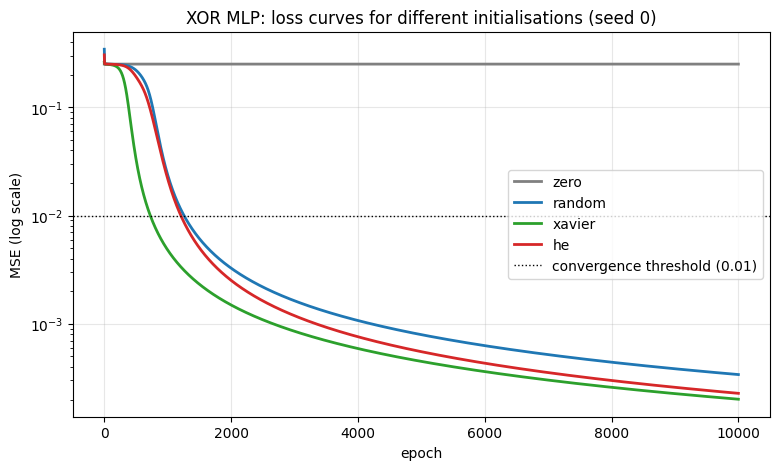

,seed-0 epochs to MSE<0.01,seed-0 final loss,median epochs (converged seeds),converged seeds,median final loss (5 seeds)
init_method,,,,,
zero,> 10000,0.25000,> 10000,0/5,0.25000
random,1258,0.00034,898,5/5,0.00025
xavier,727,0.00020,1082,5/5,0.00020
he,1208,0.00023,906,5/5,0.00022


In [ ]:
EPOCHS = 10000
methods = ["zero", "random", "xavier", "he"]
colors = {"zero": "gray", "random": "tab:blue", "xavier": "tab:green", "he": "tab:red"}

curves, summary = {}, []
for meth in methods:
    conv, finals, seed0_conv = [], [], None
    for s_ in range(5):
        m = MLPInit(n_hidden=4, lr=1.0, seed=s_, init_method=meth).fit(X, y_xor, epochs=EPOCHS)
        finals.append(m.losses_[-1])
        if m.converged_epoch_ is not None:
            conv.append(m.converged_epoch_)
        if s_ == 0:
            curves[meth] = m.losses_
            seed0_conv = m.converged_epoch_
    summary.append({
        "init_method": meth,
        "seed-0 epochs to MSE<0.01": seed0_conv if seed0_conv else f"> {EPOCHS}",
        "seed-0 final loss": f"{curves[meth][-1]:.5f}",
        "median epochs (converged seeds)": int(np.median(conv)) if conv else f"> {EPOCHS}",
        "converged seeds": f"{len(conv)}/5",
        "median final loss (5 seeds)": f"{np.median(finals):.5f}",
    })

plt.figure(figsize=(9, 5))
for meth in methods:
    plt.plot(curves[meth], label=meth, color=colors[meth], lw=2)
plt.yscale("log")
plt.axhline(0.01, color="k", ls=":", lw=1, label="convergence threshold (0.01)")
plt.xlabel("epoch"); plt.ylabel("MSE (log scale)")
plt.title("XOR MLP: loss curves for different initialisations (seed 0)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

pd.DataFrame(summary).set_index("init_method")

**Observations.**
- **zero** never learns: symmetry is never broken, loss stays near 0.25.
- **random (N(0,1))**, **Xavier** and **He** all break symmetry and solve XOR in about 700-1,300 epochs, and all 5 seeds converged for each. On this tiny 2-4-1 network the three are close: the median epochs are similar (random ~900, He ~900, Xavier ~1,100) and the differences are within seed-to-seed variation, so no scheme is clearly best here. Scaled schemes (Xavier/He) matter more in deeper networks, where they keep activations and gradients from vanishing or exploding.
- Exact epoch counts vary with seed, so the 5-seed summary is more trustworthy than a single run.

---
### Summary
| Task | Result |
|---|---|
| 1 | AND(w=[1,1],θ=2), OR(w=[1,1],θ=1), NOT(w=[−1],θ=0), AND-3(w=[1,1,1],θ=3); XOR impossible with a single M-P neuron |
| 2 | Perceptron learns AND/OR in a few epochs; fails on XOR (not linearly separable) |
| 3 | MLP with a hidden layer solves XOR; higher lr and more hidden units converge faster |
| 4 | Zero init → symmetry failure; random/Xavier/He all work |